In [ ]:
import pandas as pd

#Code montrant comment utiliser les méthodes "apply(fonction)" et "diff()" d'une Series

liste_a = [10,25,33,42,56]
series1 = pd.Series(liste_a)

#La fonction "diff()" permet de renvoyer les différences : donnee_t - donnee_t-1 
#(ou donne_t - donnee_t-k si l'on spécifie la durée des différences)
#Note : si donnee_t-k n'existe pas, la différence renvoyé est "NaN"
print("Différences :\n", series1.diff())

#La fonction "apply(fonction)" permet d'appliquer "fonction" sur les données.
#Les données peuvent être ceux de la Series, ou une transformation des données de la Series. 
#ex : ".apply(fonction).diff(k)" applique la fonction sur les différences "donnee_t - donnee_t-k"
print("\nDonnées * 2 :\n", series1.apply(lambda x: x*2))

#La fonction "describe()" permet d'afficher quelques statistiques descriptives sur les données (ou une transformation des données)
#Ex : on peut écrire "apply(fonction).describe()" ou ".diff().describe()"
print("\nStatistiques descriptives :\n",series1.apply(lambda x: x*2).describe())

Différences :
 0     NaN
1    15.0
2     8.0
3     9.0
4    14.0
dtype: float64

Données * 2 :
 0     20
1     50
2     66
3     84
4    112
dtype: int64

Statistiques descriptives :
 count      5.000000
mean      66.400000
std       34.681407
min       20.000000
25%       50.000000
50%       66.000000
75%       84.000000
max      112.000000
dtype: float64


count    124.000000
mean     263.122149
std       12.162082
min      226.358551
25%      256.148235
50%      264.464996
75%      272.727318
max      285.922455
Name: Close, dtype: float64
count    123.000000
mean       0.078010
std        1.423648
min       -5.127415
25%       -0.533606
50%        0.078581
75%        0.612431
max        4.219290
Name: Variations %, dtype: float64
Skewness : -0.06635627791304159 | Kurtosis en excès : 2.3053832227660638
Statistique JB : 24.0955 | p-value JB : 0.0000
Statistique de Jarque-Bera à la main : 27.328572684711308
Statistique SW : 0.9446 | p-value SW : 0.0001


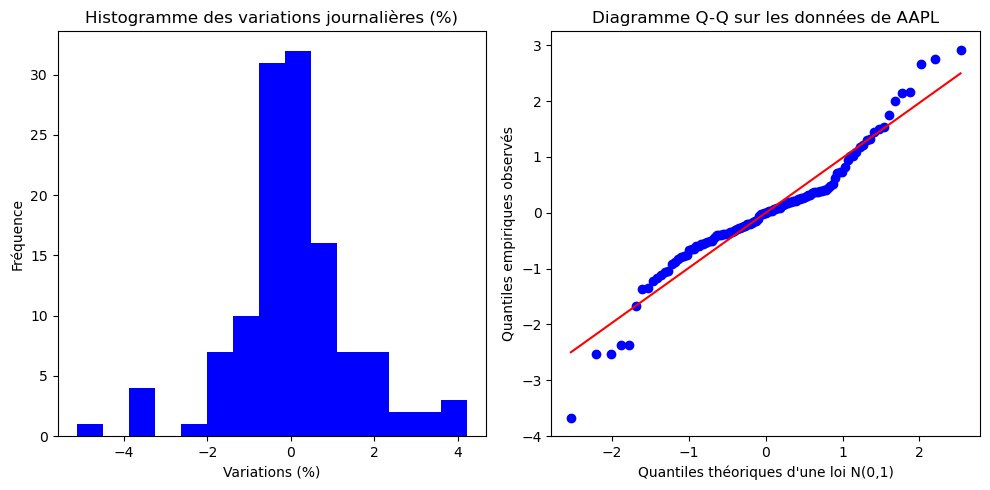

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy import stats
#Objectif de ce code : vérifier la normalité des variations journalières pour vérifier s'il est raisonnable de calculer la VaR paramétrique.
#Les données sont recueillis sur l'action "AAPL" et sur la période "09/sep/2025" à "06/mar/2026".


#Récupération des données du fichier Excel, et récupération des cours de clôture
df = pd.read_excel("C:/Users/kimis/OneDrive/Python for data analysis and finance/AAPL - data pour python.xlsx")
cours_cloture = df["Close"]
#print("Cours de clôture\n", cours_cloture)




#Création d'une nouvelle colonne/Series : calcul des variations journalières, en %.
df["Variations %"] = cours_cloture.apply(np.log).diff()*100
variations_pct = df["Variations %"].dropna()    
#On utilise la fonction "dropna()" pour supprimer la valeur NaN de la première ligne
#Cela est nécessaire pour avoir des données "propres".




#Affichage de quelques statistiques descriptives (moyenne, écart-type, min, max, quantiles à 25%, 50%, 75%)
cours_stats_descriptives = cours_cloture.describe()
variations_stats_descriptives = df["Variations %"].describe()
print(cours_stats_descriptives)
print(variations_stats_descriptives)



#Affichage du kurtosis et du skewness
print(f"Skewness : {variations_pct.skew()} | Kurtosis en excès : {variations_pct.kurtosis()}")



#Test de Jarque-Bera
#Note : il y a ici que 123 observations, donc le test ne s'applique pas (le résultat du test est inutile)
#Mais nous décidons quand même de le faire, simplement pour apprendre à l'utiliser

#Calcul de la statistique JB avec Python
stat_jb, p_value_jb = stats.jarque_bera(variations_pct)
print(f"Statistique JB : {stat_jb:.4f} | p-value JB : {p_value_jb:.4f}")

#Calcul de la statistique JB à la main
nb = len(variations_pct)
skewness = variations_pct.skew()
kurtosis = variations_pct.kurtosis()
stat_jb_main = (nb/6)*(skewness**2 + kurtosis**2/4)
print("Statistique de Jarque-Bera à la main :", stat_jb_main)



#Test de Shapiro-Wilk
stat_sw, p_value_sw = stats.shapiro(variations_pct)
print(f"Statistique SW : {stat_sw:.4f} | p-value SW : {p_value_sw:.4f}")



#Diagramme Q-Q
#On décide de centrer-réduire les données, de sorte à mieux interpréter les valeurs des quantiles dans le diagramme.
#On centre et réduit grâce à la fonction "zscore({données à centrer-réduire})"
variations_pct_centrees_reduites = stats.zscore(variations_pct)

#Création d'un cadre (fig) et d'une toile (ax) contenant 2 graphiques
fig, axes = plt.subplots(1,2)

#Dessin de l'histogramme des variations en %
variations_pct.plot(kind="hist",bins=15, figsize=(10,5), color="blue", ax=axes[0])
axes[0].set_title("Histogramme des variations journalières (%)")
axes[0].set_xlabel("Variations (%)")
axes[0].set_ylabel("Fréquence")

#Dessin du diagramme Q-Q, en utilisant la fonction "probplot({donnees},{distribution à comparer},{toile où dessiner})"
diagramme_Q_Q = stats.probplot(variations_pct_centrees_reduites,dist="norm",plot=axes[1])
axes[1].set_title("Diagramme Q-Q sur les données de AAPL")
axes[1].set_xlabel("Quantiles théoriques d'une loi N(0,1)")
axes[1].set_ylabel("Quantiles empiriques observés")

#Ajustement automatique de l'espace entre les deux graphiques et affichage des deux graphiques
plt.tight_layout()
plt.show()
print("Fin")
